# Practical No-03: Autoencoder and Variational Autoencoder for Image Reconstruction

**Task:** Build an **Autoencoder (AE)** and a **Variational Autoencoder (VAE)** to reconstruct and generate handwritten digit images, and compare their performance.

**Name :- Sneha Chaurasia**

---

**PRN :- 202401110046**

---

**Batch :- A3- AIML**

## 2. Problem Statement
Build an Autoencoder and a Variational Autoencoder (VAE) for image reconstruction and generation. Compare the performance of both models by analyzing the quality of reconstructed and generated images.

## 3. Objective
To implement an Autoencoder and a Variational Autoencoder (VAE) for reconstructing images and generating new images similar to the training data. The two models are compared on:
* Reconstruction quality
* Training loss
* Visual quality of reconstructed images
* Quality of newly generated images

## 4. Introduction
An **Autoencoder** is an unsupervised neural network that learns to compress an input into a lower-dimensional **latent space** (encoder) and then reconstruct it back (decoder). It is trained to minimize reconstruction error, so it is good at compression and denoising, but its latent space has no particular structure — points between two encoded images don't necessarily decode into a meaningful digit.

A **Variational Autoencoder (VAE)** is a generative version of this idea. Instead of mapping an input to a single latent point, the encoder outputs the **mean (μ) and log-variance (log σ²)** of a probability distribution, and a point is **sampled** from that distribution (using the **reparameterization trick**, so gradients can still flow). The loss adds a **KL-divergence** term that pushes the latent distribution toward a standard normal distribution. This makes the latent space continuous and well-organized, so the VAE can also **generate new images** by sampling random points from that normal distribution and decoding them — something a plain Autoencoder cannot do reliably.

**Key difference:**
| | Autoencoder | Variational Autoencoder |
|---|---|---|
| Latent representation | Fixed point | Probability distribution (μ, σ) |
| Loss | Reconstruction loss only | Reconstruction loss + KL divergence |
| Latent space | Not continuous / not structured | Continuous, structured (≈ Normal) |
| Can generate new images | Not reliably | Yes |

## 5. Dataset Description
**MNIST Handwritten Digit Dataset**

| Field | Details |
|---|---|
| Total images | 70,000 |
| Image size | 28 × 28 pixels |
| Classes | 10 (digits 0–9) |
| Image type | Grayscale |
| Training set | 60,000 images |
| Testing set | 10,000 images |

MNIST is used because its small grayscale images make it easy to see reconstruction and generation quality directly. It is loaded directly through `tf.keras.datasets.mnist.load_data()`.

## 6. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import tensorflow.keras.backend as K

# Reproducibility
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

sns.set_style("whitegrid")
print("TensorFlow version:", tf.__version__)
print("GPU available     :", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 7. Load Dataset

In [2]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"x_train: {x_train.shape} | y_train: {y_train.shape}")
print(f"x_test : {x_test.shape} | y_test : {y_test.shape}")
print(f"Pixel value range: [{x_train.min()}, {x_train.max()}]")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train: (60000, 28, 28) | y_train: (60000,)
x_test : (10000, 28, 28) | y_test : (10000,)
Pixel value range: [0, 255]


## 8. Dataset Visualization

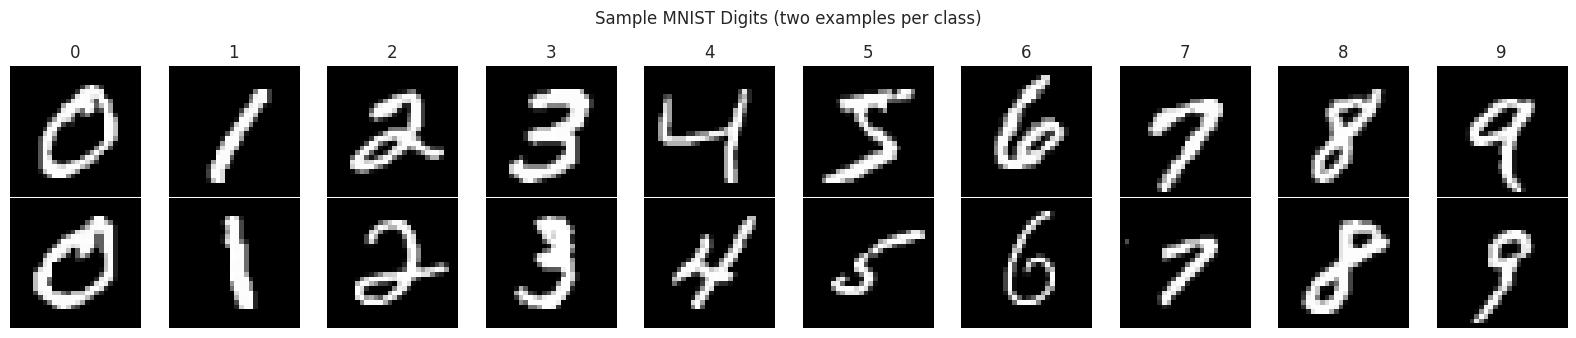

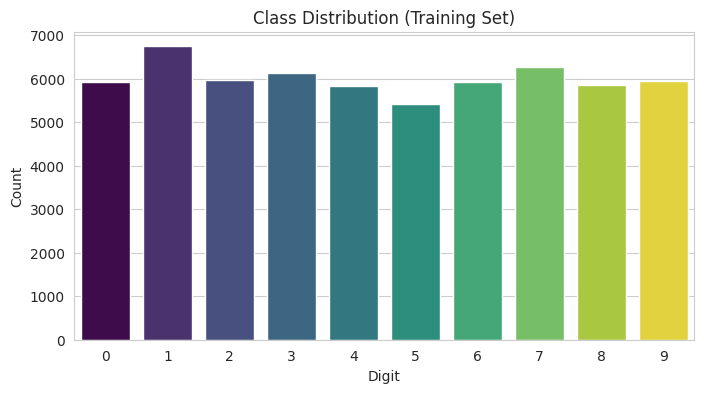

In [3]:
fig, axes = plt.subplots(2, 10, figsize=(16, 3.4))
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    axes[0, digit].imshow(x_train[idx], cmap="gray")
    axes[0, digit].set_title(str(digit)); axes[0, digit].axis("off")
    idx2 = np.where(y_train == digit)[0][1]
    axes[1, digit].imshow(x_train[idx2], cmap="gray")
    axes[1, digit].axis("off")
plt.suptitle("Sample MNIST Digits (two examples per class)")
plt.tight_layout(); plt.show()

# Class distribution
labels, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
sns.barplot(x=labels, y=counts, hue=labels, palette="viridis", legend=False)
plt.title("Class Distribution (Training Set)"); plt.xlabel("Digit"); plt.ylabel("Count")
plt.show()

## 9. Data Preprocessing
Images are normalized to `[0, 1]` (required for the sigmoid output of the decoder) and flattened to 784-dimensional vectors, since both models here use a **Dense (fully-connected) architecture**. Labels are kept only for visualizing the latent space, not for training (both models are unsupervised).

In [4]:
x_train_n = x_train.astype("float32") / 255.0
x_test_n  = x_test.astype("float32") / 255.0

x_train_flat = x_train_n.reshape(-1, 784)
x_test_flat  = x_test_n.reshape(-1, 784)

print(f"x_train_flat: {x_train_flat.shape} | x_test_flat: {x_test_flat.shape}")

LATENT_DIM = 16

x_train_flat: (60000, 784) | x_test_flat: (10000, 784)


## 10. Autoencoder

### 10.1 Build Encoder
`784 → 256 → 64 → LATENT_DIM`. Each Dense layer uses ReLU activation except the final latent layer, which is linear.

In [5]:
def build_ae_encoder(latent_dim=LATENT_DIM):
    inputs = keras.Input(shape=(784,), name="ae_encoder_input")
    x = layers.Dense(256, activation="relu")(inputs)
    x = layers.Dense(64, activation="relu")(x)
    latent = layers.Dense(latent_dim, activation=None, name="ae_latent")(x)
    return Model(inputs, latent, name="AE_Encoder")

ae_encoder = build_ae_encoder()
ae_encoder.summary()

Model: "AE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_encoder_input (InputLayer)   │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae_latent (Dense)               │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,448 (853.31 KB)

 Trainable params: 218,448 (853.31 KB)

 Non-trainable params: 0 (0.00 B)

### 10.2 Build Decoder
Mirrors the encoder: `LATENT_DIM → 64 → 256 → 784`, with a sigmoid output since pixels are in `[0, 1]`.

In [6]:
def build_ae_decoder(latent_dim=LATENT_DIM):
    latent_inputs = keras.Input(shape=(latent_dim,), name="ae_decoder_input")
    x = layers.Dense(64, activation="relu")(latent_inputs)
    x = layers.Dense(256, activation="relu")(x)
    outputs = layers.Dense(784, activation="sigmoid")(x)
    return Model(latent_inputs, outputs, name="AE_Decoder")

ae_decoder = build_ae_decoder()
ae_decoder.summary()

Model: "AE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_decoder_input (InputLayer)   │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,216 (856.31 KB)

 Trainable params: 219,216 (856.31 KB)

 Non-trainable params: 0 (0.00 B)

### 10.3 Build Autoencoder

In [7]:
ae_inputs = keras.Input(shape=(784,), name="ae_input")
ae_latent = ae_encoder(ae_inputs)
ae_outputs = ae_decoder(ae_latent)
autoencoder = Model(ae_inputs, ae_outputs, name="Autoencoder")

### 10.4 Model Summary

In [8]:
autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input (InputLayer)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ AE_Encoder (Functional)         │ (None, 16)             │       218,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ AE_Decoder (Functional)         │ (None, 784)            │       219,216 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 437,664 (1.67 MB)

 Trainable params: 437,664 (1.67 MB)

 Non-trainable params: 0 (0.00 B)

### 10.5 Compile
Binary cross-entropy is used as the reconstruction loss since pixel values are treated as probabilities in `[0, 1]`; MSE would also be valid.

In [9]:
autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
print("Autoencoder compiled.")

Autoencoder compiled.


### 10.6 Train

In [10]:
ae_history = autoencoder.fit(
    x_train_flat, x_train_flat,
    validation_data=(x_test_flat, x_test_flat),
    epochs=20,
    batch_size=256,
    shuffle=True,
    verbose=1,
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2198 - val_loss: 0.1469
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1333 - val_loss: 0.1225
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1179 - val_loss: 0.1127
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1114 - val_loss: 0.1081
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1079 - val_loss: 0.1055
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1055 - val_loss: 0.1035
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1036 - val_loss: 0.1019
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1022 - val_loss: 0.1005
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1009 - val_loss: 0.0994
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0999 - val_loss: 0.0986
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0990 - val_loss: 0.0978
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/ste

### 10.7 Plot Training Loss

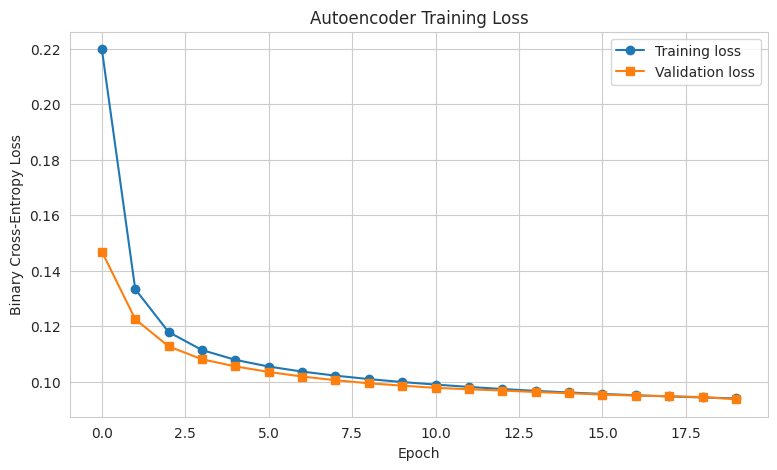

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(ae_history.history["loss"], "o-", label="Training loss")
plt.plot(ae_history.history["val_loss"], "s-", label="Validation loss")
plt.title("Autoencoder Training Loss"); plt.xlabel("Epoch"); plt.ylabel("Binary Cross-Entropy Loss")
plt.legend(); plt.grid(True); plt.show()

### 10.8 Reconstruct Images

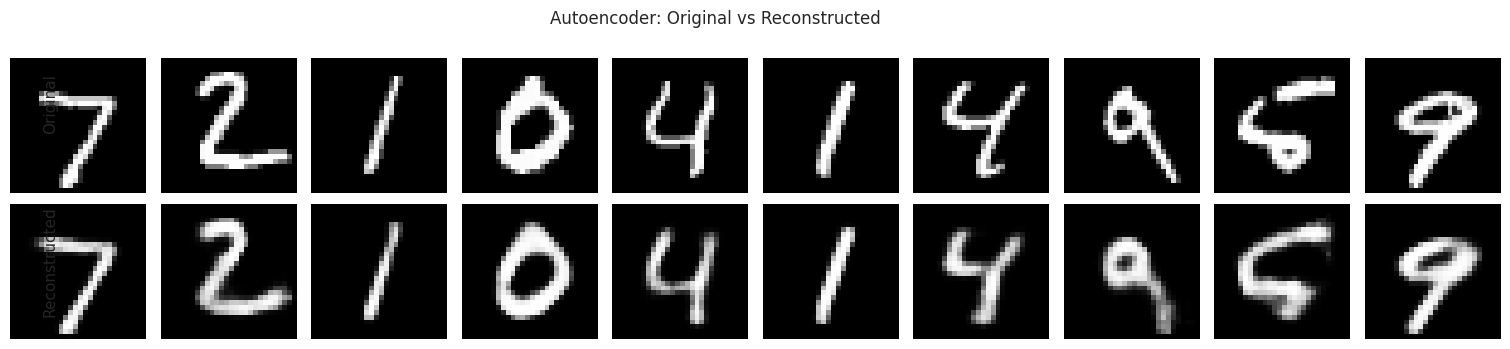

Autoencoder test reconstruction loss (BCE): 0.0937


In [12]:
n = 10
test_imgs = x_test_flat[:n]
ae_recon = autoencoder.predict(test_imgs, verbose=0)

fig, axes = plt.subplots(2, n, figsize=(16, 3.6))
for i in range(n):
    axes[0, i].imshow(test_imgs[i].reshape(28, 28), cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(ae_recon[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=11); axes[1, 0].set_ylabel("Reconstructed", fontsize=11)
fig.text(0.08, 0.72, "Original", rotation=90, va="center", fontsize=11)
fig.text(0.08, 0.28, "Reconstructed", rotation=90, va="center", fontsize=11)
plt.suptitle("Autoencoder: Original vs Reconstructed")
plt.tight_layout(rect=[0.05, 0, 1, 1]); plt.show()

ae_test_loss = autoencoder.evaluate(x_test_flat, x_test_flat, verbose=0)
print(f"Autoencoder test reconstruction loss (BCE): {ae_test_loss:.4f}")

## 11. Variational Autoencoder

### 11.1 Encoder
Same Dense backbone as the AE encoder (`784 → 256 → 64`), but instead of one latent output it produces **two** vectors: `z_mean` and `z_log_var`.

In [13]:
vae_inputs = keras.Input(shape=(784,), name="vae_encoder_input")
x = layers.Dense(256, activation="relu")(vae_inputs)
x = layers.Dense(64, activation="relu")(x)

### 11.2 Latent Mean and Variance
`z_mean` and `z_log_var` parametrize a Gaussian distribution for each input in the latent space.

In [14]:
z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)

### 11.3 Sampling
The **reparameterization trick**: `z = z_mean + exp(0.5 * z_log_var) * epsilon`, where `epsilon ~ N(0, I)`. This lets gradients flow through the sampling step during backpropagation.

In [15]:
class Sampling(layers.Layer):
    """Samples z from (z_mean, z_log_var) using the reparameterization trick."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim), seed=SEED)
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = Sampling(name="z_sampling")([z_mean, z_log_var])
vae_encoder = Model(vae_inputs, [z_mean, z_log_var, z], name="VAE_Encoder")
vae_encoder.summary()

Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_encoder_input   │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    200,960 │ vae_encoder_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │     16,448 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │      1,040 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │      1,040 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_sampling          │ (None, 16)        │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 219,488 (857.38 KB)

 Trainable params: 219,488 (857.38 KB)

 Non-trainable params: 0 (0.00 B)

### 11.4 Decoder

In [16]:
def build_vae_decoder(latent_dim=LATENT_DIM):
    latent_inputs = keras.Input(shape=(latent_dim,), name="vae_decoder_input")
    x = layers.Dense(64, activation="relu")(latent_inputs)
    x = layers.Dense(256, activation="relu")(x)
    outputs = layers.Dense(784, activation="sigmoid")(x)
    return Model(latent_inputs, outputs, name="VAE_Decoder")

vae_decoder = build_vae_decoder()
vae_decoder.summary()

Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vae_decoder_input (InputLayer)  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,216 (856.31 KB)

 Trainable params: 219,216 (856.31 KB)

 Non-trainable params: 0 (0.00 B)

### 11.5 VAE Model
The VAE is wrapped as a custom `Model` subclass so the loss (reconstruction + KL divergence) can be computed and added inside `train_step`.

**Loss** = Reconstruction loss (BCE, summed over pixels) + KL divergence:
`KL = -0.5 * sum(1 + log_var - mean^2 - exp(log_var))`

The KL term forces the latent distribution toward `N(0, I)`, which makes the latent space continuous and usable for generation.

In [17]:
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data[..., None], reconstruction[..., None]), axis=1)
            )
            kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            kl_loss = tf.reduce_mean(kl_loss)
            total_loss = recon_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(data[..., None], reconstruction[..., None]), axis=1)
        )
        kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        kl_loss = tf.reduce_mean(kl_loss)
        total_loss = recon_loss + kl_loss
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

vae = VAE(vae_encoder, vae_decoder, name="VAE")
vae.compile(optimizer=keras.optimizers.Adam(1e-3))
print("VAE built and compiled.")

VAE built and compiled.


### 11.6 Train

In [18]:
vae_history = vae.fit(
    x_train_flat,
    validation_data=(x_test_flat,),
    epochs=20,
    batch_size=256,
    shuffle=True,
    verbose=1,
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - kl_loss: 8.3808 - loss: 201.7712 - reconstruction_loss: 193.3906 - val_kl_loss: 13.0056 - val_loss: 155.5550 - val_reconstruction_loss: 142.5494
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - kl_loss: 15.0065 - loss: 144.9483 - reconstruction_loss: 129.9417 - val_kl_loss: 17.1069 - val_loss: 135.4115 - val_reconstruction_loss: 118.3046
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - kl_loss: 17.4643 - loss: 132.0713 - reconstruction_loss: 114.6070 - val_kl_loss: 17.8489 - val_loss: 127.0317 - val_reconstruction_loss: 109.1828
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - kl_loss: 18.5989 - loss: 125.5325 - reconstruction_loss: 106.9336 - val_kl_loss: 19.3040 - val_loss: 122.0381 - val_reconstruction_loss: 102.7340
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - kl_loss: 19.3589 - loss: 121.5007 - reconstruction_loss: 102.1417 - val_kl_loss: 19.7503 - val_loss: 118.7085 - val_reconstruction_loss: 98.9582
E

### 11.7 Plot Loss

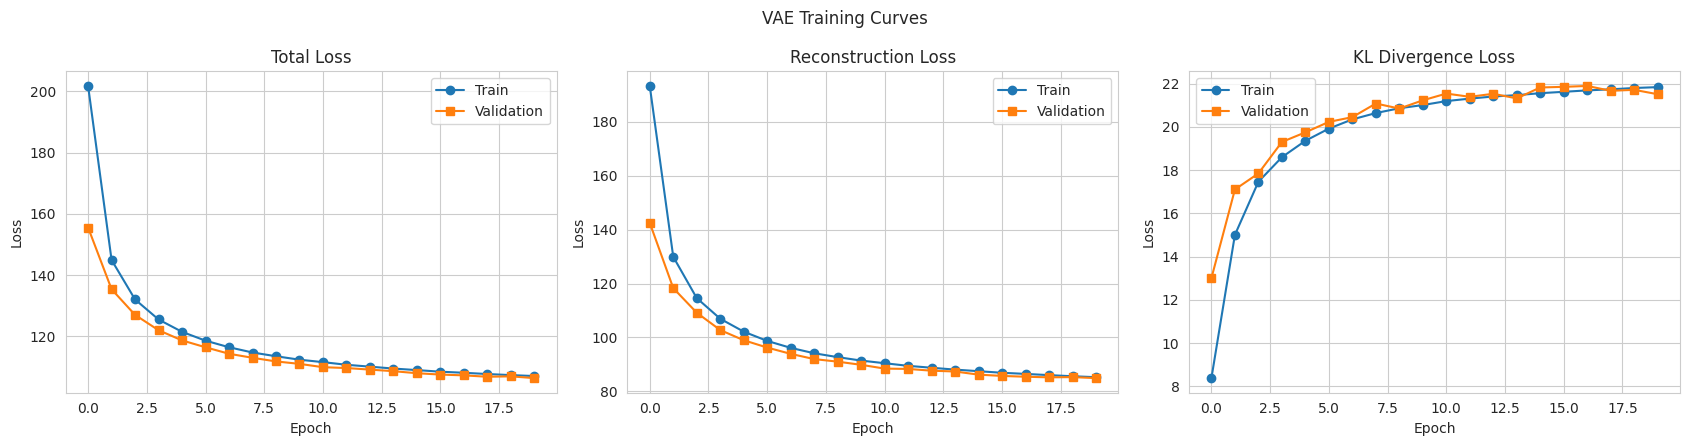

In [19]:
h = vae_history.history
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, key, title in zip(
    axes,
    ["loss", "reconstruction_loss", "kl_loss"],
    ["Total Loss", "Reconstruction Loss", "KL Divergence Loss"],
):
    ax.plot(h[key], "o-", label="Train")
    if f"val_{key}" in h:
        ax.plot(h[f"val_{key}"], "s-", label="Validation")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(); ax.grid(True)
plt.suptitle("VAE Training Curves")
plt.tight_layout(); plt.show()

### 11.8 Reconstruct Images

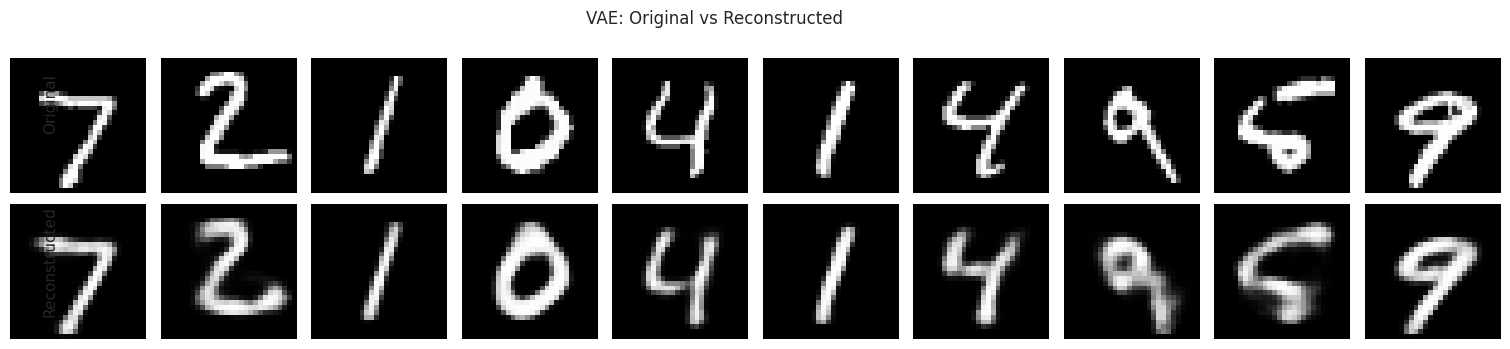

VAE test total loss          : 106.5871
VAE test reconstruction loss : 85.0930
VAE test KL divergence loss  : 21.4941


In [20]:
z_mean_test, z_log_var_test, z_test = vae_encoder.predict(test_imgs, verbose=0)
vae_recon = vae_decoder.predict(z_mean_test, verbose=0)  # use the mean for deterministic reconstruction

fig, axes = plt.subplots(2, n, figsize=(16, 3.6))
for i in range(n):
    axes[0, i].imshow(test_imgs[i].reshape(28, 28), cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(vae_recon[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
fig.text(0.08, 0.72, "Original", rotation=90, va="center", fontsize=11)
fig.text(0.08, 0.28, "Reconstructed", rotation=90, va="center", fontsize=11)
plt.suptitle("VAE: Original vs Reconstructed")
plt.tight_layout(rect=[0.05, 0, 1, 1]); plt.show()

vae_test_metrics = vae.evaluate(x_test_flat, verbose=0)
print(f"VAE test total loss          : {vae_test_metrics[0]:.4f}")
print(f"VAE test reconstruction loss : {vae_test_metrics[1]:.4f}")
print(f"VAE test KL divergence loss  : {vae_test_metrics[2]:.4f}")

### 11.9 Generate New Images
Because the VAE's latent space is regularized toward `N(0, I)`, new digit images can be generated by sampling random latent vectors from a standard normal distribution and passing them through the decoder — something the plain Autoencoder's latent space does not support reliably.

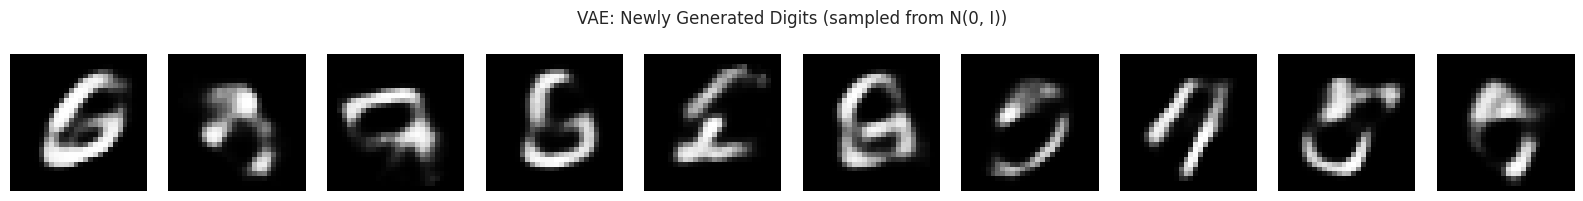

In [21]:
n_gen = 10
random_latent = np.random.normal(size=(n_gen, LATENT_DIM))
generated_imgs = vae_decoder.predict(random_latent, verbose=0)

fig, axes = plt.subplots(1, n_gen, figsize=(16, 2))
for i in range(n_gen):
    axes[i].imshow(generated_imgs[i].reshape(28, 28), cmap="gray"); axes[i].axis("off")
plt.suptitle("VAE: Newly Generated Digits (sampled from N(0, I))")
plt.tight_layout(); plt.show()

In [22]:
# 2D latent space visualization (trained separately with LATENT_DIM=2, for intuition only)
vae_2d_encoder_in = keras.Input(shape=(784,))
h2 = layers.Dense(256, activation="relu")(vae_2d_encoder_in)
h2 = layers.Dense(64, activation="relu")(h2)
z_mean_2d = layers.Dense(2, name="z_mean_2d")(h2)
z_log_var_2d = layers.Dense(2, name="z_log_var_2d")(h2)
z_2d = Sampling()([z_mean_2d, z_log_var_2d])
enc_2d = Model(vae_2d_encoder_in, [z_mean_2d, z_log_var_2d, z_2d], name="VAE_Encoder_2D")
dec_2d = build_vae_decoder(latent_dim=2)
vae_2d = VAE(enc_2d, dec_2d, name="VAE_2D")
vae_2d.compile(optimizer=keras.optimizers.Adam(1e-3))
vae_2d.fit(x_train_flat, epochs=10, batch_size=256, shuffle=True, verbose=1)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - kl_loss: 5.3995 - loss: 220.6912 - reconstruction_loss: 215.2918
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.3124 - loss: 178.1158 - reconstruction_loss: 173.8034
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.6535 - loss: 171.4353 - reconstruction_loss: 166.7818
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.7466 - loss: 168.4663 - reconstruction_loss: 163.7196
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.8936 - loss: 166.0792 - reconstruction_loss: 161.1855
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.0563 - loss: 163.7593 - reconstruction_loss: 158.7030
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.2566 - loss: 161.0474 - reconstruction_loss: 155.7909
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.4246 - loss: 158.6231 - reconstruction_loss: 153.1985
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

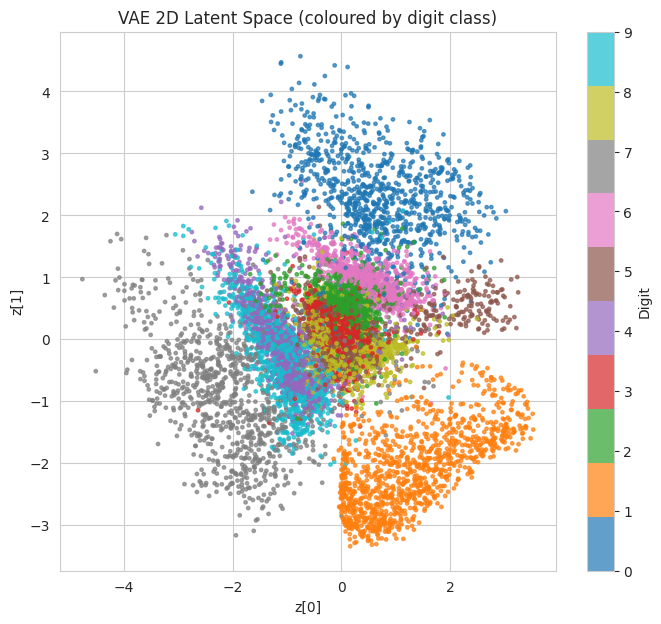

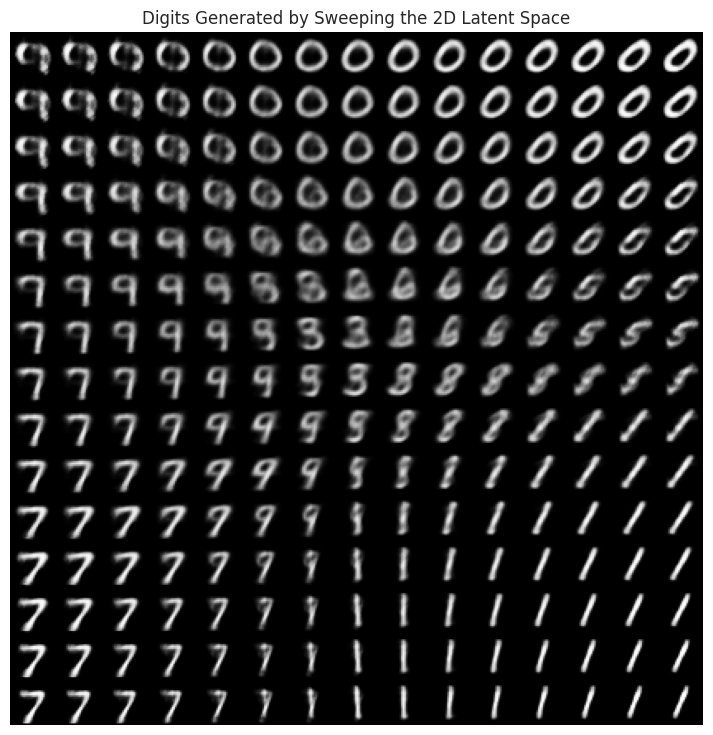

In [23]:
# Plot the 2D latent space coloured by digit label
z_mean_2d_test, _, _ = enc_2d.predict(x_test_flat, verbose=0)
plt.figure(figsize=(8, 7))
scatter = plt.scatter(z_mean_2d_test[:, 0], z_mean_2d_test[:, 1], c=y_test, cmap="tab10", s=6, alpha=0.7)
plt.colorbar(scatter, label="Digit")
plt.title("VAE 2D Latent Space (coloured by digit class)")
plt.xlabel("z[0]"); plt.ylabel("z[1]")
plt.show()

# Grid of digits generated by sweeping the 2D latent space
grid_n = 15
grid_x = np.linspace(-3, 3, grid_n)
grid_y = np.linspace(-3, 3, grid_n)[::-1]
canvas = np.zeros((28 * grid_n, 28 * grid_n))
for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        decoded = dec_2d.predict(z_sample, verbose=0)[0].reshape(28, 28)
        canvas[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = decoded

plt.figure(figsize=(9, 9))
plt.imshow(canvas, cmap="gray")
plt.title("Digits Generated by Sweeping the 2D Latent Space")
plt.axis("off"); plt.show()

## 12. Comparison

In [27]:
comparison = {
    "Aspect": ["Final train loss", "Final validation/test loss", "Can generate new images",
               "Latent space structure", "Reconstruction sharpness"],
    "Autoencoder": [f"{ae_history.history['loss'][-1]:.4f} (BCE)",
                     f"{ae_test_loss:.4f} (BCE)",
                     "No (latent space not continuous)",
                     "Unstructured",
                     "Sharper (no distributional constraint)"],
    "VAE": [f"{vae_history.history['loss'][-1]:.4f} (BCE+KL)",
            f"{vae_test_metrics[0]:.4f} (BCE+KL)",
            "Yes (sample z ~ N(0,I) and decode)",
            "Continuous, Gaussian-like",
            "Slightly blurrier (regularized by KL term)"],
}
import pandas as pd
pd.DataFrame(comparison)

,Aspect,Autoencoder,VAE
0,Final train loss,0.0940 (BCE),107.0702 (BCE+KL)
1,Final validation/test loss,0.0937 (BCE),106.5871 (BCE+KL)
2,Can generate new images,No (latent space not continuous),"Yes (sample z ~ N(0,I) and decode)"
3,Latent space structure,Unstructured,"Continuous, Gaussian-like"
4,Reconstruction sharpness,Sharper (no distributional constraint),Slightly blurrier (regularized by KL term)


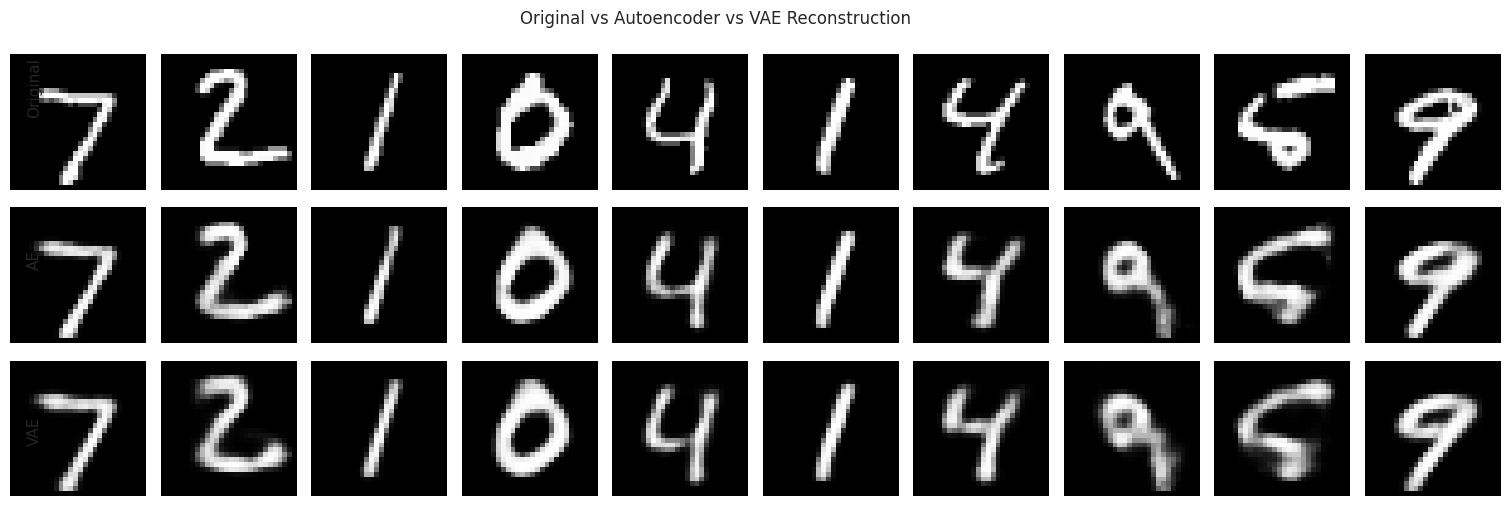

In [25]:
# Side-by-side visual comparison: original vs AE vs VAE reconstruction
fig, axes = plt.subplots(3, n, figsize=(16, 5.2))
for i in range(n):
    axes[0, i].imshow(test_imgs[i].reshape(28, 28), cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(ae_recon[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(vae_recon[i].reshape(28, 28), cmap="gray"); axes[2, i].axis("off")
fig.text(0.07, 0.83, "Original", rotation=90, va="center", fontsize=11)
fig.text(0.07, 0.5, "AE", rotation=90, va="center", fontsize=11)
fig.text(0.07, 0.17, "VAE", rotation=90, va="center", fontsize=11)
plt.suptitle("Original vs Autoencoder vs VAE Reconstruction")
plt.tight_layout(rect=[0.05, 0, 1, 1]); plt.show()

## 13. Results

In [26]:
print("=" * 50)
print("           FINAL RESULTS")
print("=" * 50)
print(f"Autoencoder - final train loss      : {ae_history.history['loss'][-1]:.4f}")
print(f"Autoencoder - test reconstruction loss: {ae_test_loss:.4f}")
print()
print(f"VAE - final train total loss        : {vae_history.history['loss'][-1]:.4f}")
print(f"VAE - test total loss               : {vae_test_metrics[0]:.4f}")
print(f"VAE - test reconstruction loss      : {vae_test_metrics[1]:.4f}")
print(f"VAE - test KL divergence loss       : {vae_test_metrics[2]:.4f}")
print("=" * 50)
print(f"Autoencoder parameters: {autoencoder.count_params():,}")
print(f"VAE parameters        : {vae_encoder.count_params() + vae_decoder.count_params():,}")

           FINAL RESULTS
Autoencoder - final train loss      : 0.0940
Autoencoder - test reconstruction loss: 0.0937

VAE - final train total loss        : 107.0702
VAE - test total loss               : 106.5871
VAE - test reconstruction loss      : 85.0930
VAE - test KL divergence loss       : 21.4941
Autoencoder parameters: 437,664
VAE parameters        : 438,704


## 14. Conclusion
Both an Autoencoder and a Variational Autoencoder were built, trained and evaluated on the MNIST dataset. The Autoencoder learns a compact latent representation purely to minimize reconstruction error, giving sharp reconstructions but an unstructured latent space unsuitable for generation. The VAE adds a probabilistic latent representation (mean and variance, sampled using the reparameterization trick) and a KL-divergence regularization term, which makes its latent space continuous and approximately Gaussian. This lets the VAE both reconstruct existing images and **generate new, realistic digit images** by sampling random latent vectors — a capability the plain Autoencoder does not reliably offer.

**Trade-off:** Autoencoder = sharper reconstructions, no generation. VAE = slightly blurrier reconstructions, but meaningful generation and a structured latent space.

**Possible improvements:** Convolutional encoder/decoder layers (instead of Dense) for sharper images, a higher latent dimensionality, beta-VAE (weighting the KL term) to control the sharpness/structure trade-off, and conditional VAE (CVAE) to generate digits of a chosen class.

##✅Declaration

I, **Sneha Chaurasia** confirm that this implementation was prepared for Practical Assignment 3 and that the results presented are generated from the experiments performed in this notebook.

GitHub Repository Link: https://github.com/Sneha529-oss/Autoencoder-and-VAE-for-Image-Reconstruction-Practical-No.-03-Gen-AI